In [21]:
from pathlib import Path
import json

import h5py
import numpy as np
import qutip as qt
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from data import ReconstructionDataset, stratified_split
from recon import StateReconstructor
from rho import rho_from_params

In [22]:
root = Path.cwd().parent.parent
h5_path = root / "scripts" / "data" / "sweep" / "train_noisy_14000.h5"  # dopasuj nazwę do tego, co wygenerowałeś

print(f"Dataset: {h5_path}")
ds = ReconstructionDataset(h5_path)
print(f"Liczba próbek: {len(ds)}")

Dataset: /home/sebas/qsdl/scripts/data/sweep/train_noisy_14000.h5
Liczba próbek: 14000


In [23]:
train_idx, test_idx, val_idx = stratified_split(len(ds), 67, 80, 10, 10)

train_loader = DataLoader(ReconstructionDataset(h5_path, indices=train_idx), batch_size=32, shuffle=True)
val_loader   = DataLoader(ReconstructionDataset(h5_path, indices=val_idx),   batch_size=32, shuffle=False)
test_loader  = DataLoader(ReconstructionDataset(h5_path, indices=test_idx),  batch_size=32, shuffle=False)  # shuffle=False jest KRYTYCZNE — patrz komórka 8

print(f"train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}")

train=11200  val=1400  test=1400


In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

model = StateReconstructor().to(device)
optimizer = optim.AdamW(model.parameters(), lr=3e-4)
loss_fn = nn.MSELoss().to(device)

cpu


In [25]:
epochs = 50
history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")
best_state = None

for epoch in tqdm(range(1, epochs + 1), desc="Training"):
    # ---- TRAIN ----
    model.train()
    train_loss = 0.0
    for w, rho_true in tqdm(train_loader, desc=f"Epoka {epoch}/{epochs}", leave=False):
        w, rho_true = w.to(device), rho_true.to(device)

        params = model(w)
        rho_hat = rho_from_params(params, N=64)

        loss = loss_fn(rho_hat.real, rho_true.real) + loss_fn(rho_hat.imag, rho_true.imag)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * w.size(0)

    train_loss /= len(train_loader.dataset)

    # ---- VAL ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for w, rho_true in val_loader:
            w, rho_true = w.to(device), rho_true.to(device)
            params = model(w)
            rho_hat = rho_from_params(params, N=64)
            loss = loss_fn(rho_hat.real, rho_true.real) + loss_fn(rho_hat.imag, rho_true.imag)
            val_loss += loss.item() * w.size(0)

    val_loss /= len(val_loader.dataset)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoka {epoch}/{epochs} | train loss {train_loss:.6f} | val loss {val_loss:.6f}")

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Epoka 1/50:   0%|          | 0/350 [00:00<?, ?it/s]

Epoka 1/50 | train loss 0.000159 | val loss 0.000130


Epoka 2/50:   0%|          | 0/350 [00:00<?, ?it/s]

Epoka 2/50 | train loss 0.000123 | val loss 0.000113


...

Epoka 48/50 | train loss 0.000059 | val loss 0.000054


Epoka 49/50:   0%|          | 0/350 [00:00<?, ?it/s]

Epoka 49/50 | train loss 0.000058 | val loss 0.000054


Epoka 50/50:   0%|          | 0/350 [00:00<?, ?it/s]

Epoka 50/50 | train loss 0.000058 | val loss 0.000056


In [26]:
model.load_state_dict(best_state)

models_dir = root / "models"
models_dir.mkdir(exist_ok=True)
model_path = models_dir / "sweep_reconstructor.pt"

torch.save(model.state_dict(), model_path)
print(f"Zapisano model → {model_path}  (best val loss = {best_val_loss:.6f})")

Zapisano model → /home/sebas/qsdl/models/sweep_reconstructor.pt  (best val loss = 0.000054)


In [27]:
with h5py.File(h5_path, "r") as f:
    metadata_all = f["metadata"][:]

test_meta = [json.loads(metadata_all[i]) for i in test_idx]
print(f"Metadane dla {len(test_meta)} próbek testowych wczytane")

Metadane dla 1400 próbek testowych wczytane


In [28]:
model.eval()

by_level = {}   # loss_pct -> lista fidelity
ptr = 0

with torch.no_grad():
    for w, rho_true in tqdm(test_loader, desc="Liczenie fidelity"):
        w = w.to(device)
        pred = model(w)
        rho_hat = rho_from_params(pred, N=64).cpu().numpy()
        rho_true_np = rho_true.numpy()

        for b in range(len(rho_hat)):
            fid = qt.fidelity(qt.Qobj(rho_true_np[b]), qt.Qobj(rho_hat[b]))
            eta = test_meta[ptr].get("photonL", 1.0)
            loss_pct = round((1.0 - eta) * 100)

            by_level.setdefault(loss_pct, []).append(fid)
            ptr += 1

assert ptr == len(test_meta), "kolejność próbek się rozjechała — sprawdź shuffle=False"

Liczenie fidelity:   0%|          | 0/44 [00:00<?, ?it/s]

In [29]:
results = []
for loss_pct in sorted(by_level):
    fids = np.array(by_level[loss_pct])
    results.append({
        "loss_pct": loss_pct,
        "mean_fidelity": float(fids.mean()),
        "std_fidelity": float(fids.std()),
        "min_fidelity": float(fids.min()),
        "max_fidelity": float(fids.max()),
        "n_samples": int(len(fids)),
    })

for r in results:
    print(f"{r['loss_pct']:3d}% strat | fidelity = {r['mean_fidelity']:.4f} ± {r['std_fidelity']:.4f}  (n={r['n_samples']})")

 20% strat | fidelity = 0.9187 ± 0.0787  (n=87)
 25% strat | fidelity = 0.8974 ± 0.1111  (n=72)
 30% strat | fidelity = 0.9241 ± 0.0583  (n=82)
 35% strat | fidelity = 0.9077 ± 0.0989  (n=81)
 40% strat | fidelity = 0.9039 ± 0.0719  (n=82)
 45% strat | fidelity = 0.9116 ± 0.0739  (n=76)
 50% strat | fidelity = 0.8950 ± 0.0780  (n=78)
 55% strat | fidelity = 0.8794 ± 0.0886  (n=87)
 60% strat | fidelity = 0.8767 ± 0.0935  (n=91)
 65% strat | fidelity = 0.8818 ± 0.0957  (n=90)
 70% strat | fidelity = 0.8471 ± 0.1190  (n=77)
 75% strat | fidelity = 0.8016 ± 0.1507  (n=81)
 80% strat | fidelity = 0.7571 ± 0.1746  (n=114)
 85% strat | fidelity = 0.7340 ± 0.1777  (n=78)
 90% strat | fidelity = 0.7100 ± 0.2097  (n=77)
 95% strat | fidelity = 0.6424 ± 0.2412  (n=79)
100% strat | fidelity = 0.4432 ± 0.3044  (n=68)


In [30]:
results_dir = root / "results"
results_dir.mkdir(exist_ok=True)
results_path = results_dir / "photon_loss_fidelity.json"

with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Zapisano wyniki → {results_path}")

Zapisano wyniki → /home/sebas/qsdl/results/photon_loss_fidelity.json


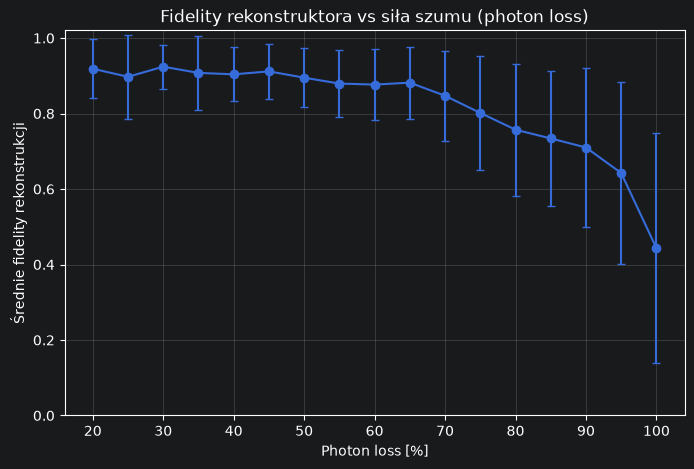

Zapisano wykres → /home/sebas/qsdl/figures/photon_loss_fidelity.png


In [31]:
import matplotlib.pyplot as plt

xs = [r["loss_pct"] for r in results]
ys = [r["mean_fidelity"] for r in results]
yerr = [r["std_fidelity"] for r in results]

plt.figure(figsize=(8, 5))
plt.errorbar(xs, ys, yerr=yerr, marker="o", capsize=3)
plt.xlabel("Photon loss [%]")
plt.ylabel("Średnie fidelity rekonstrukcji")
plt.title("Fidelity rekonstruktora vs siła szumu (photon loss)")
plt.grid(alpha=0.3)
plt.ylim(0, 1.02)

figures_dir = root / "figures"
figures_dir.mkdir(exist_ok=True)
fig_path = figures_dir / "photon_loss_fidelity.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Zapisano wykres → {fig_path}")